In [28]:
import seaborn as sns
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from dateutil.relativedelta import relativedelta
from scipy.optimize import curve_fit
from scipy.stats import lognorm

In [31]:
#import the CSV containing real-world "permanent" chains data (permanent means that they reached high percentage for more weeks)
input_file = "Dataset_predominant_chains_from_data.csv"
df = pd.read_csv(input_file)

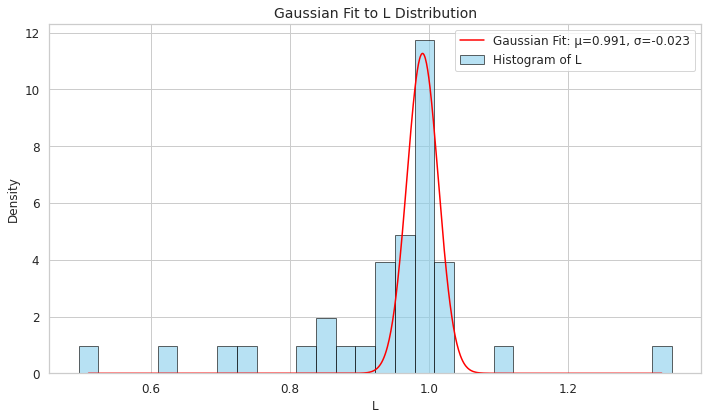

Fitted Gaussian Parameters:
Amplitude: 11.264
Mean (mu): 0.991
Standard Deviation (sigma): -0.023


In [32]:
#Gaussian function for fitting L parameter distribution (Figure S15 (c))
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

L_values = df['L'].dropna() 

counts, bin_edges = np.histogram(L_values, bins=30, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#Gaussian fit initializing mu (mean) around 1
initial_guess = [1, 1, 0.5]  # amp, mu, sigma

popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=initial_guess)

amp_opt, mu_opt, sigma_opt = popt

x_fit = np.linspace(min(bin_centers), max(bin_centers), 1000)
y_fit = gaussian(x_fit, amp_opt, mu_opt, sigma_opt)

plt.figure(figsize=(10, 6))
plt.hist(L_values, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram of L')
plt.plot(x_fit, y_fit, color='red', label=f'Gaussian Fit: μ={mu_opt:.3f}, σ={sigma_opt:.3f}')
plt.title('Gaussian Fit to L Distribution', fontsize=14)
plt.xlabel('L', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True)
plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout() 
plt.savefig("Figure_S15_(c).pdf", dpi=300, bbox_inches='tight')
plt.show()
print(f'Fitted Gaussian Parameters:\nAmplitude: {amp_opt:.3f}\nMean (mu): {mu_opt:.3f}\nStandard Deviation (sigma): {sigma_opt:.3f}')

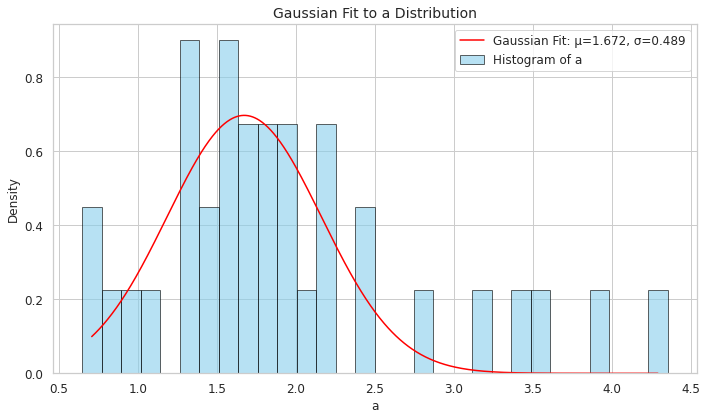

Fitted Gaussian Parameters:
Amplitude: 0.697
Mean (mu): 1.672
Standard Deviation (sigma): 0.489


In [33]:
#extract coloumn parameter a
a_values = df['a'].dropna()
counts, bin_edges = np.histogram(a_values, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mean_a = np.mean(a_values)
initial_guess = [1, mean_a, 0.5]  # amp, mu (mean of a), sigma

popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=initial_guess)
amp_opt, mu_opt, sigma_opt = popt
x_fit = np.linspace(min(bin_centers), max(bin_centers), 1000)
y_fit = gaussian(x_fit, amp_opt, mu_opt, sigma_opt)

plt.figure(figsize=(10, 6))
plt.hist(a_values, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram of a')
plt.plot(x_fit, y_fit, color='red', label=f'Gaussian Fit: μ={mu_opt:.3f}, σ={sigma_opt:.3f}')
plt.title('Gaussian Fit to a Distribution', fontsize=14)
plt.xlabel('a', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True)
plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout() 
plt.savefig("Figure_S15_(a).pdf", dpi=300, bbox_inches='tight')
plt.show()
print(f'Fitted Gaussian Parameters:\nAmplitude: {amp_opt:.3f}\nMean (mu): {mu_opt:.3f}\nStandard Deviation (sigma): {sigma_opt:.3f}')

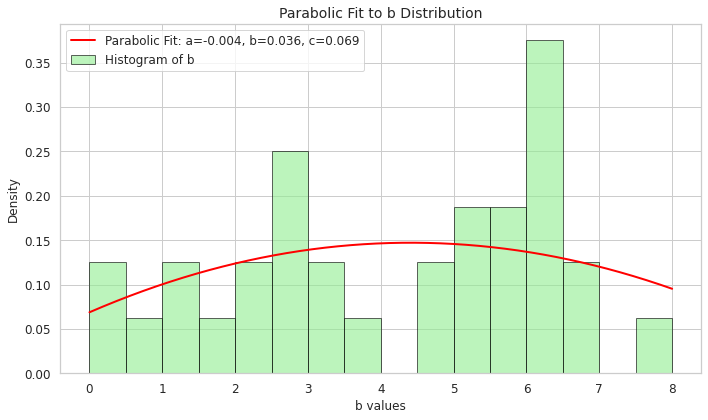

Fitted Parabolic Parameters:
a: -0.004027
b: 0.035522
c: 0.068730


In [34]:
b_values = df['b'].dropna()
b_min, b_max = 0, 8
b_values_filtered = b_values[(b_values >= b_min) & (b_values <= b_max)]
num_bins = 16
bins = np.linspace(b_min, b_max, num_bins + 1)
counts, bin_edges = np.histogram(b_values_filtered, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

initial_guess = [-1, 0, max(counts)]  # a negative for concavity
bounds = ([-np.inf, -np.inf, 0], [0, np.inf, np.inf])  # a ≤ 0 for concavity
popt, _ = curve_fit(parabola, bin_centers, counts, p0=initial_guess, bounds=bounds)
a_opt, b_opt, c_opt = popt
x_fit = np.linspace(b_min, b_max, 1000)
y_fit = parabola(x_fit, *popt)

plt.figure(figsize=(10, 6))
plt.hist(b_values_filtered, bins=bins, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Histogram of b')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Parabolic Fit: a={a_opt:.3f}, b={b_opt:.3f}, c={c_opt:.3f}')
plt.title('Parabolic Fit to b Distribution', fontsize=14)
plt.xlabel('b values', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True)
plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout() 
plt.savefig("Figure_S15_(b).pdf", dpi=300, bbox_inches='tight')
plt.show()
print(f'Fitted Parabolic Parameters:\na: {a_opt:.6f}\nb: {b_opt:.6f}\nc: {c_opt:.6f}')

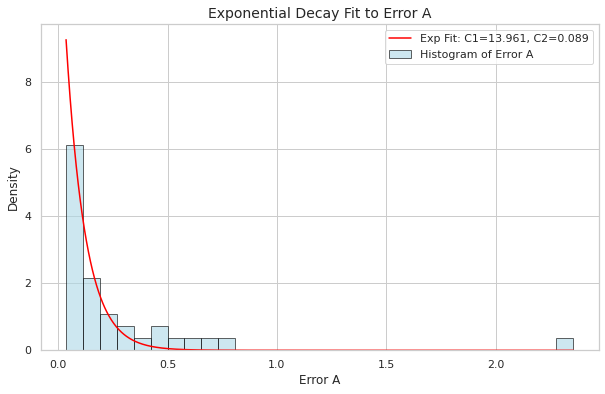

Fitted parameters for Error A:
C1 = 13.961
C2 = 0.089


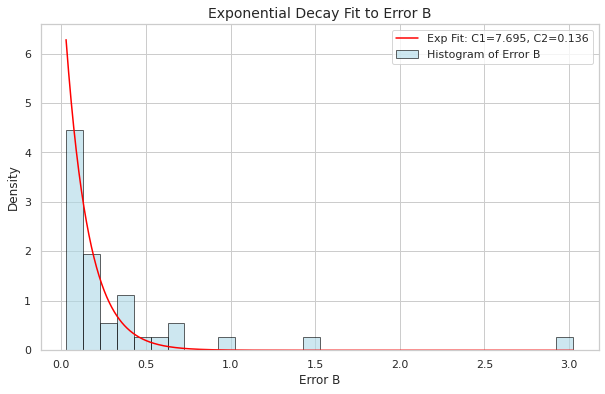

Fitted parameters for Error B:
C1 = 7.695
C2 = 0.136


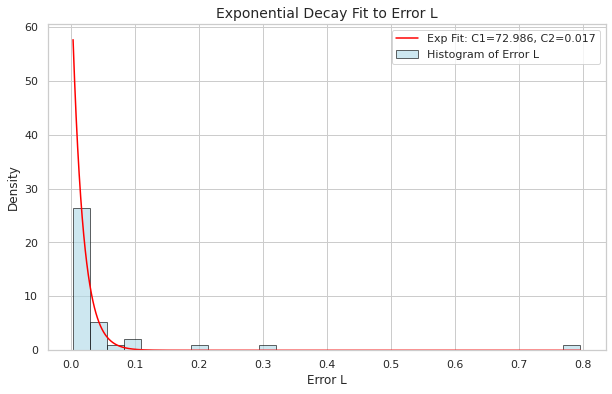

Fitted parameters for Error L:
C1 = 72.986
C2 = 0.017


In [35]:
#exponential function definition
def exp_decay(x, C1, C2):
    return C1 * np.exp(-x / C2)

def fit_and_plot(column, label):
    data = df[column].dropna()
    counts, bin_edges = np.histogram(data, bins=30, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    initial_guess = [1, 1]  # Stima iniziale per C1 e C2
    popt, pcov = curve_fit(exp_decay, bin_centers, counts, p0=initial_guess)
    C1_opt, C2_opt = popt
    x_fit = np.linspace(min(data), max(data), 1000)
    y_fit = exp_decay(x_fit, C1_opt, C2_opt)

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=30, density=True, alpha=0.6, color='lightblue', edgecolor='black', label=f'Histogram of {label}')
    plt.plot(x_fit, y_fit, color='red', label=f'Exp Fit: C1={C1_opt:.3f}, C2={C2_opt:.3f}')
    plt.title(f'Exponential Decay Fit to {label}', fontsize=14)
    plt.xlabel(label, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f'Fitted parameters for {label}:\nC1 = {C1_opt:.3f}\nC2 = {C2_opt:.3f}')

fit_and_plot('error_a', 'Error A')
fit_and_plot('error_b', 'Error B')
fit_and_plot('error_L', 'Error L')

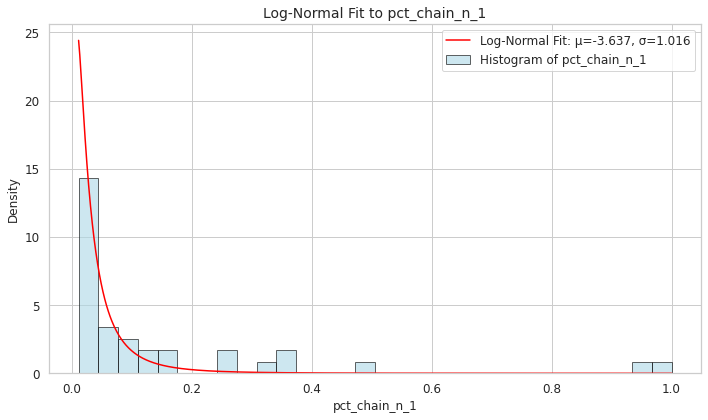

Fitted parameters (lognorm): μ=-3.637, σ=1.016


In [36]:
#log-norm function for the fit
def lognorm_dist(x, mu, sigma):
    return lognorm.pdf(x, s=sigma, scale=np.exp(mu))

def fit_and_plot_lognorm(column, label):
    data = df[column].dropna()
    counts, bin_edges = np.histogram(data, bins=30, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    popt, _ = curve_fit(lognorm_dist, bin_centers, counts, p0=[0, 0.5])  # μ e σ iniziali
    x_fit = np.linspace(min(data), max(data), 1000)
    y_fit = lognorm_dist(x_fit, *popt)
    label_fit = f'Log-Normal Fit: μ={popt[0]:.3f}, σ={popt[1]:.3f}'
    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=30, density=True, alpha=0.6, color='lightblue', edgecolor='black', label=f'Histogram of {label}')
    plt.plot(x_fit, y_fit, color='red', label=label_fit)
    plt.title(f'Log-Normal Fit to {label}', fontsize=14)
    plt.xlabel(label, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=12)
    plt.tick_params(labelsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("Figure_S15_(d).pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Fitted parameters (lognorm): μ={popt[0]:.3f}, σ={popt[1]:.3f}')

fit_and_plot_lognorm('pct_chain_n_1', 'pct_chain_n_1')

In [37]:
min_b = df['b'].min()
max_b = df['b'].max()

print(f"Min value of b: {min_b}")
print(f"Max value of b: {max_b}")

Min value of b: 0.0259933404700953
Max value of b: 8.38953574407904


In [38]:
#parameters from the parabolic fit of b: ax² + bx + c
a_par, b_par, c_par = -0.004027, 0.035522, 0.068730  

#parameters from the distributions of a and L parameters
mu_L, sigma_L = 0.991, 0.023  # Gaussiana of L
mu_a, sigma_a = 1.672, 0.489  # Gaussiana of a

#parameters from the lognorm fit of pct_chain_n_1
lognorm_shape, lognorm_loc = -3.63721567, 1.01629321  

#chosen number of chains to generate
N = 10000

#limits on b (obtained from real-world data)
b_min = 0.0259933404700953  
b_max = 8.38953574407904    

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

def sample_b_from_parabola(N, b_min, b_max, a, b, c):
    x_vals = np.linspace(b_min, b_max, 10000) 
    y_vals = parabola(x_vals, a, b, c)
    y_vals = np.maximum(y_vals, 0)
    y_probs = y_vals / np.sum(y_vals)
    
    return np.random.choice(x_vals, size=N, p=y_probs)

def sample_pct_chain_n_1_from_lognorm(N, shape, loc):
    return np.random.lognormal(mean=shape, sigma=loc, size=N)

b_sim_values = sample_b_from_parabola(N, b_min, b_max, a_par, b_par, c_par)
pct_chain_n_1_values = sample_pct_chain_n_1_from_lognorm(N, lognorm_shape, lognorm_loc)

def generate_chain(index):
    L_sim = np.random.normal(mu_L, sigma_L)
    a_sim = np.random.normal(mu_a, sigma_a)
    b_sim = b_sim_values[index]
    pct_chain_n_1_sim = pct_chain_n_1_values[index]
    
    return a_sim, b_sim, L_sim, pct_chain_n_1_sim

generated_chains = [generate_chain(i) for i in range(N)]

columns = ['a', 'b', 'L', 'pct_chain_n_1']
df_simulated = pd.DataFrame(generated_chains, columns=columns)

df_simulated.to_csv('simulated_predominant_chains.csv', index=False)

print(df_simulated.head())

          a         b         L  pct_chain_n_1
0  1.226580  6.325207  0.970873       0.073469
1  1.633741  5.479568  0.994736       0.027026
2  1.094729  6.387103  0.977770       0.011693
3  1.470090  1.213735  0.998052       0.005936
4  1.172962  5.291370  1.015604       0.011714


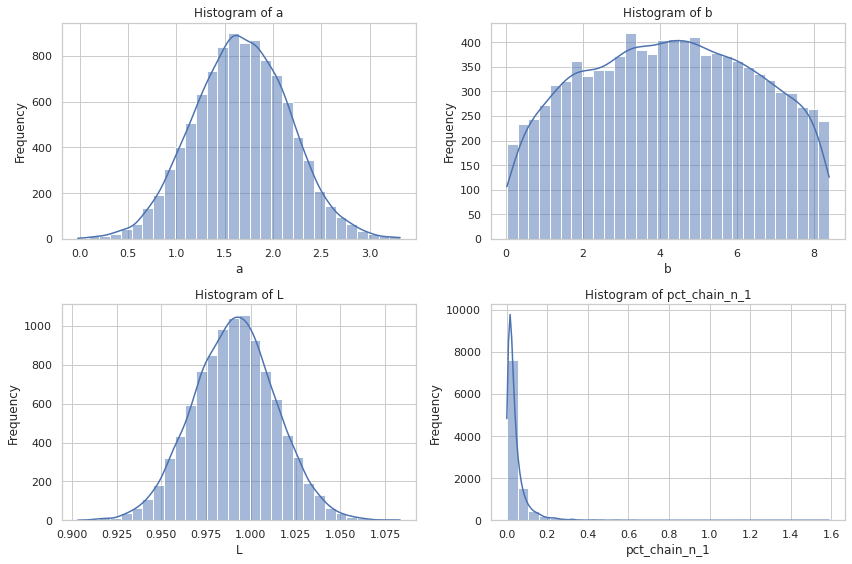

In [39]:
sns.set(style="whitegrid")

#histo for each parameter
plt.figure(figsize=(12, 8))

for i, column in enumerate(df_simulated.columns, 1):
    plt.subplot(2, 2, i)  # 2x2 grid
    sns.histplot(df_simulated[column], bins=30, kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [40]:
#sigmoid function for fitting simulated chains as for real-world ones
def sigmoid(t, a, b, L):
    return L / (1 + np.exp(-a * (t - b)))

#function for exponential distribution of errors
def exp_decay(x, C1, C2):
    return C1 * np.exp(-x / C2)

#function for perturbation (otherwise we have too perfect unrealistic chains)
def sample_perturbation(error_dist_params):
    delta = np.random.exponential(scale=error_dist_params[1])  # Scale = C2 dal fit
    sign = np.random.choice([-1, 1])  # Scelta casuale tra + o -
    return sign * delta

#sigmoid growth function
def growth_function(t, a, b, L):
    return L / (1 + np.exp(-a * (t - b)))

#adding column for pct_chains_n_1 retrieved as the value at which t=0 (by definition, since it's the percentage of the chain at week 1)
df_simulated['pct_chain_n_1'] = df_simulated['L'] / (1 + np.exp(df_simulated['b'] / df_simulated['a']))

#parameter for exponential errors
error_params_a = (16.817, 0.081)  #values obtained from the fit of 'a'
error_params_b = (11.075, 0.102)  #values obtained from the fit of 'b'
error_params_L = (46.898, 0.025)  #values obtained from the fit of 'L'

for idx, row in df_simulated.iterrows():
    a, b, L = row['a'], row['b'], row['L']
    pct_chain_n_1 = row['pct_chain_n_1']

    # Generate perturbed points from t=0 to t=30
    perturbed_points = []
    for delta_t in range(1, 31):  
        a_prime = a + sample_perturbation(error_params_a)
        b_prime = b + sample_perturbation(error_params_b)
        L_prime = L + sample_perturbation(error_params_L)
        perturbed_point = growth_function(delta_t, a_prime, b_prime, L_prime)
        perturbed_points.append(perturbed_point)
        
    for i, point in enumerate(perturbed_points, start=1):
        df_simulated.at[idx, f'pct_chain_n_{i + 1}'] = point  # Nomina pct_chain_n_2, pct_chain_n_3, ecc.

df_simulated.to_csv('simulated_predominant_chains.csv', index=False)
print(df_simulated.head())

          a         b         L  pct_chain_n_1  pct_chain_n_2  pct_chain_n_3  \
0  1.226580  6.325207  0.970873       0.005560       0.001196       0.004269   
1  1.633741  5.479568  0.994736       0.033587       0.000565       0.006628   
2  1.094729  6.387103  0.977770       0.002852       0.002321       0.014340   
3  1.470090  1.213735  0.998052       0.303979       0.559526       0.765769   
4  1.172962  5.291370  1.015604       0.011036       0.007008       0.016530   

   pct_chain_n_4  pct_chain_n_5  pct_chain_n_6  pct_chain_n_7  ...  \
0       0.023445       0.043240       0.147712       0.412634  ...   
1       0.046892       0.122300       0.431177       0.657791  ...   
2       0.038195       0.080551       0.166817       0.434561  ...   
3       0.935714       1.002420       0.976136       0.995622  ...   
4       0.043747       0.203817       0.416466       0.705944  ...   

   pct_chain_n_22  pct_chain_n_23  pct_chain_n_24  pct_chain_n_25  \
0        0.972776        1.00

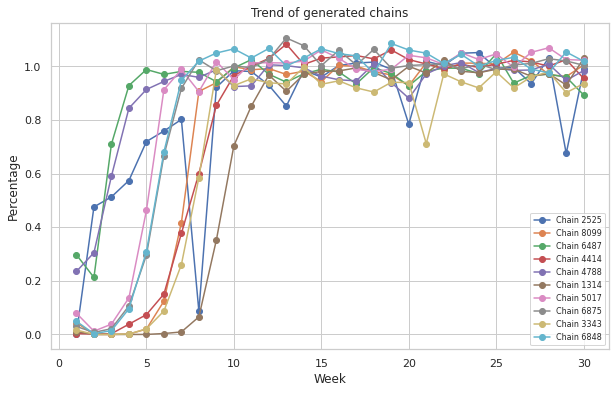

In [41]:
#plot some sample curves to check
plt.figure(figsize=(10, 6))

num_samples = min(10, len(df_simulated)) #taking 10 random curves
sampled_rows = df_simulated.sample(num_samples)

for idx, row in sampled_rows.iterrows():
    t_values = np.arange(1, 31)  # Da week 1 a week 30
    pct_values = [row[f'pct_chain_n_{week}'] for week in t_values]

    plt.plot(t_values, pct_values, marker='o', linestyle='-', label=f'Chain {idx}')

plt.xlabel("Week")
plt.ylabel("Percentage")
plt.title("Trend of generated chains")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()

In [42]:
def fit_sigmoid(t_values, pct_values):
    if any(np.isnan(pct_values)) or len(t_values) < 3:
        return np.nan, np.nan, np.nan  #avoid errors for unsufficient data

    initial_guess = [0.5, np.mean(t_values), max(pct_values)]
    bounds = ([0, min(t_values), 0], [10, max(t_values) * 1.5, max(pct_values) * 1.5])

    try:
        popt, _ = curve_fit(sigmoid, t_values, pct_values, p0=initial_guess, bounds=bounds, maxfev=10000)
    except (RuntimeError, ValueError):
        popt = [np.nan, np.nan, np.nan]  

    return popt

for idx, row in df_simulated.iterrows():
    t_values = [0, 1, 2]
    pct_values = [row[f'pct_chain_n_{i}'] for i in range(1, 4)]
    
    a3, b3, L3 = fit_sigmoid(t_values, pct_values)
    df_simulated.at[idx, 'a3'] = a3
    df_simulated.at[idx, 'b3'] = b3
    df_simulated.at[idx, 'L3'] = L3

    t_values.append(3)
    pct_values.append(row['pct_chain_n_4'])
    a4, b4, L4 = fit_sigmoid(t_values, pct_values)
    df_simulated.at[idx, 'a4'] = a4
    df_simulated.at[idx, 'b4'] = b4
    df_simulated.at[idx, 'L4'] = L4

    t_values.append(4)
    pct_values.append(row['pct_chain_n_5'])
    a5, b5, L5 = fit_sigmoid(t_values, pct_values)
    df_simulated.at[idx, 'a5'] = a5
    df_simulated.at[idx, 'b5'] = b5
    df_simulated.at[idx, 'L5'] = L5

df_simulated.to_csv('simulated_predominant_chains.csv', index=False)
print("Updated dataset with the fit values")

/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Updated dataset with the fit values


In [43]:
#compute derivatives of the parameters between week 3 and 4
df_simulated["a4'"] = df_simulated["a4"] - df_simulated["a3"]
df_simulated["b4'"] = df_simulated["b4"] - df_simulated["b3"]
df_simulated["L4'"] = df_simulated["L4"] - df_simulated["L3"]

df_simulated = df_simulated.reset_index(drop=True)
df_simulated.index = df_simulated.index + 1 

columns_order = ['pct_chain_n_1', 'pct_chain_n_2', 'pct_chain_n_3',
                 'a3', 'b3', 'L3', 
                 'a4', 'b4', 'L4', 
                 "a4'", "b4'", "L4'", 
                 'a', 'b', 'L']

#add the `label` con value 1 (meaning predominant chain, while 0 will be for transient chain)
df_final = df_simulated[columns_order].copy()
df_final.insert(0, 'chain', df_simulated.index)
df_final['label'] = 1
print(df_final.head())
df_final.to_csv("simulated_predominant_chains.csv", index=False)

   chain  pct_chain_n_1  pct_chain_n_2  pct_chain_n_3            a3        b3  \
1      1       0.005560       0.001196       0.004269  2.353217e-07  0.303710   
2      2       0.033587       0.000565       0.006628  5.291763e-15  2.045773   
3      3       0.002852       0.002321       0.014340  2.544452e+00  1.738655   
4      4       0.303979       0.559526       0.765769  1.138272e+00  0.630180   
5      5       0.011036       0.007008       0.016530  4.679991e-01  1.341908   

         L3        a4        b4        L4       a4'       b4'       L4'  \
1  0.007350  2.590040  2.736334  0.035167  2.590039  2.432623  0.027818   
2  0.027187  2.883281  2.762000  0.070338  2.883281  0.716227  0.043151   
3  0.021510  1.790398  2.614361  0.057292 -0.754054  0.875706  0.035782   
4  0.926809  0.942095  0.943032  1.065091 -0.196177  0.312852  0.138282   
5  0.024795  1.340966  2.598071  0.065621  0.872967  1.256163  0.040826   

          a         b         L  label  
1  1.226580  6.325207